In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
train_path ="Training"
test_path = "Testing"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.25,
    shear_range=0.15,

    brightness_range=[0.8,1.2],

    horizontal_flip=True,

    fill_mode='nearest'
)
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [4]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [5]:
model = Sequential()

model.add(Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Conv2D(256,(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(GlobalAveragePooling2D())

model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4,activation='softmax'))

c:\Users\hermon hw7\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "brain_tumor_cnn.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [8]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=25,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 483s 3s/step - accuracy: 0.6310 - loss: 0.9022 - val_accuracy: 0.2545 - val_loss: 1.3932
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 404s 3s/step - accuracy: 0.7306 - loss: 0.6996 - val_accuracy: 0.2759 - val_loss: 2.1185
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 460s 3s/step - accuracy: 0.7712 - loss: 0.6030 - val_accuracy: 0.3348 - val_loss: 2.0532
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 512s 3s/step - accuracy: 0.8062 - loss: 0.5170 - val_accuracy: 0.4964 - val_loss: 1.2437
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 411s 3s/step - accuracy: 0.8161 - loss: 0.4812 - val_accuracy: 0.6741 - val_loss: 0.8106
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.8270 - loss: 0.4451 - val_accuracy: 0.8277 - val_loss: 0.4435
Epoch 7/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 435s 3s/step - accuracy: 0.8433 - loss: 0.4160 - val_accuracy: 0.7455 - val_loss: 0.6680
Epoch 8/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.8502 - loss: 0.4030 - val_accu

In [9]:
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 858ms/step - accuracy: 0.7694 - loss: 0.7861
Test Accuracy: 0.7693750262260437


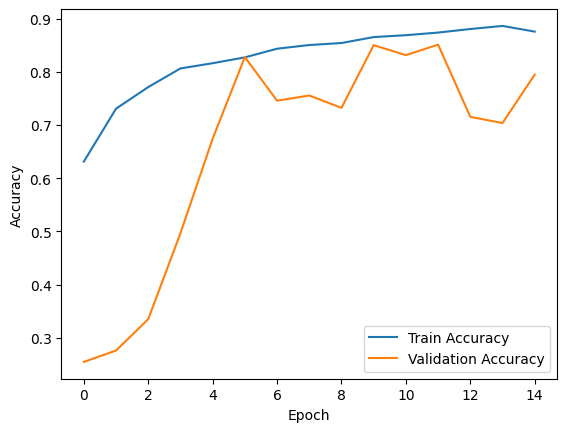

In [10]:
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

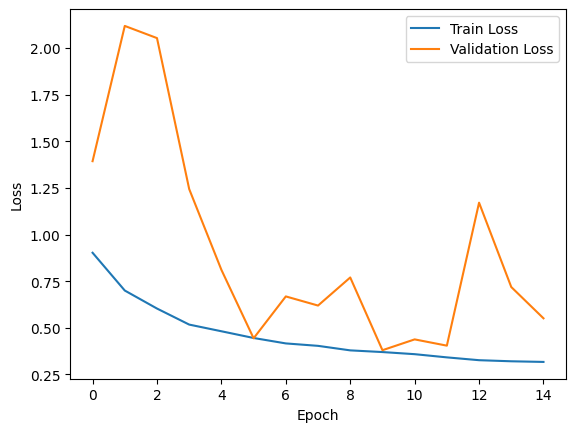

In [11]:
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

pred = model.predict(test_generator)
pred_classes = np.argmax(pred, axis=1)

print(confusion_matrix(test_generator.classes, pred_classes))

print(classification_report(
    test_generator.classes,
    pred_classes,
    target_names=list(test_generator.class_indices.keys())
))

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 250ms/step
[[237  61  60  42]
 [ 28 201  86  85]
 [  0   0 400   0]
 [  2   5   0 393]]
              precision    recall  f1-score   support

      glioma       0.89      0.59      0.71       400
  meningioma       0.75      0.50      0.60       400
     notumor       0.73      1.00      0.85       400
   pituitary       0.76      0.98      0.85       400

    accuracy                           0.77      1600
   macro avg       0.78      0.77      0.75      1600
weighted avg       0.78      0.77      0.75      1600



In [13]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    r"C:\Users\hermon hw7\OneDrive\Desktop\AIML\project\Testing\glioma\Te-gl_1.jpg",
    target_size=(224,224)
)

img = image.img_to_array(img)
img = img/255.0
img = np.expand_dims(img,0)

prediction = model.predict(img)

classes = ['glioma','meningioma','notumor','pituitary']

print(classes[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
notumor
